# Cours 1 — Régression linéaire simple et multiple
## Machine Learning Supervisé · Regression

> **Dataset fil rouge :** California Housing (`sklearn.datasets`)

---

###  Objectifs du cours

| # | Objectif | Compétence |
|---|----------|-----------|
| 1 | Formuler un problème de régression et l'distinguer de la classification | C3.3 |
| 2 | Comprendre et implémenter la régression linéaire simple (MSE, descente de gradient) | C3.3 |
| 3 | Étendre au cas multiple : multicolinéarité, standardisation | C3.3 |
| 4 | Coder et interpréter les modèles avec scikit-learn | C3.3 / C3.4 |


---
##  Setup — Imports et configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

# Style global
plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
sns.set_palette("deep")

print(" Imports OK")

 Imports OK


---
## Partie 1 — Poser un problème de régression
### 1.1 Régression vs Classification

La première question face à un problème de ML supervisé : **quelle est la nature de la variable cible y ?**

| | **Régression** | **Classification** |
|---|---|---|
| **y est...** | Continue (prix, température, CA…) | Discrète (spam/non-spam, A/B/C…) |
| **Exemples** | Prix d'une maison, consommation kWh | Fraude/non-fraude, diagnostic médical |
| **Sortie du modèle** | Un nombre réel ∈ ℝ | Une classe ou une probabilité |
| **Métriques** | MSE, RMSE, R² | Accuracy, F1, AUC-ROC |

> **Piège — variables ordinales** : une note de 1 à 5 étoiles *semble* continue mais est discrète. Si y prend moins de 10–15 valeurs distinctes, envisagez la classification.

---

### 1.2 Anatomie d'un dataset de régression

Avant tout modèle, maîtriser le vocabulaire :

| Notation | Nom | Signification |
|----------|-----|---------------|
| `X` | Matrice des features | Shape `(n_samples, n_features)` — les variables explicatives |
| `y` | Vecteur cible | Shape `(n_samples,)` — la variable à prédire |
| `n` | Nb d'observations | Nb de lignes. Ex : 20 640 maisons |
| `p` | Nb de features | Nb de colonnes de X. Ex : 8 variables |
| `ŷᵢ` | Prédiction pour i | Valeur estimée par le modèle pour l'observation i |
| `εᵢ` | Résidu | Erreur : `εᵢ = yᵢ − ŷᵢ` |


In [3]:
import os
os.environ.pop("SSLKEYLOGFILE", None)

'\\\\?\\Volume{ba5fbc33-b5dd-4468-b9fb-349269ef43b8}\\virtual_file.log'

In [4]:
# ── Chargement du dataset fil rouge ──────────────────────────────────────────
data = fetch_california_housing(as_frame=True)
df   = data.frame   # DataFrame complet (features + target)

print("=" * 55)
print(f"  Dataset : California Housing")
print(f"  Forme   : {df.shape}  ({df.shape[0]} maisons × {df.shape[1]} colonnes)")
print("=" * 55)
print()
print(df.head(3).to_string())
print()
print("Variable cible (MedHouseVal) : prix médian en 100 000 $")
print(f"  Moyenne : {df['MedHouseVal'].mean():.2f}   "
      f"Écart-type : {df['MedHouseVal'].std():.2f}   "
      f"Min : {df['MedHouseVal'].min():.2f}   "
      f"Max : {df['MedHouseVal'].max():.2f}")

  Dataset : California Housing
  Forme   : (20640, 9)  (20640 maisons × 9 colonnes)

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  Longitude  MedHouseVal
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88    -122.23        4.526
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86    -122.22        3.585
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85    -122.24        3.521

Variable cible (MedHouseVal) : prix médian en 100 000 $
  Moyenne : 2.07   Écart-type : 1.15   Min : 0.15   Max : 5.00


In [5]:
# ── Séparer X et y ───────────────────────────────────────────────────────────
X = df.drop(columns='MedHouseVal')
y = df['MedHouseVal']

print("Description des features :")
print("-" * 60)
descriptions = {
    'MedInc':      'Revenu médian du quartier (en 10 000 $)',
    'HouseAge':    'Âge médian des logements (années)',
    'AveRooms':    'Nombre moyen de pièces par ménage',
    'AveBedrms':   'Nombre moyen de chambres par ménage',
    'Population':  'Population du quartier',
    'AveOccup':    'Nombre moyen d\'occupants par ménage',
    'Latitude':    'Latitude géographique',
    'Longitude':   'Longitude géographique',
}
for col in X.columns:
    print(f"  {col:<12} → {descriptions[col]}")
print()
print(f"X shape : {X.shape}   |   y shape : {y.shape}")

Description des features :
------------------------------------------------------------
  MedInc       → Revenu médian du quartier (en 10 000 $)
  HouseAge     → Âge médian des logements (années)
  AveRooms     → Nombre moyen de pièces par ménage
  AveBedrms    → Nombre moyen de chambres par ménage
  Population   → Population du quartier
  AveOccup     → Nombre moyen d'occupants par ménage
  Latitude     → Latitude géographique
  Longitude    → Longitude géographique

X shape : (20640, 8)   |   y shape : (20640,)


### 1.3 Visualisation exploratoire

>  **Règle d'or** : on ne construit jamais de modèle avant d'avoir regardé les données.  
> La visualisation révèle : la forme de la relation (linéaire ?), les outliers, et les corrélations entre features.


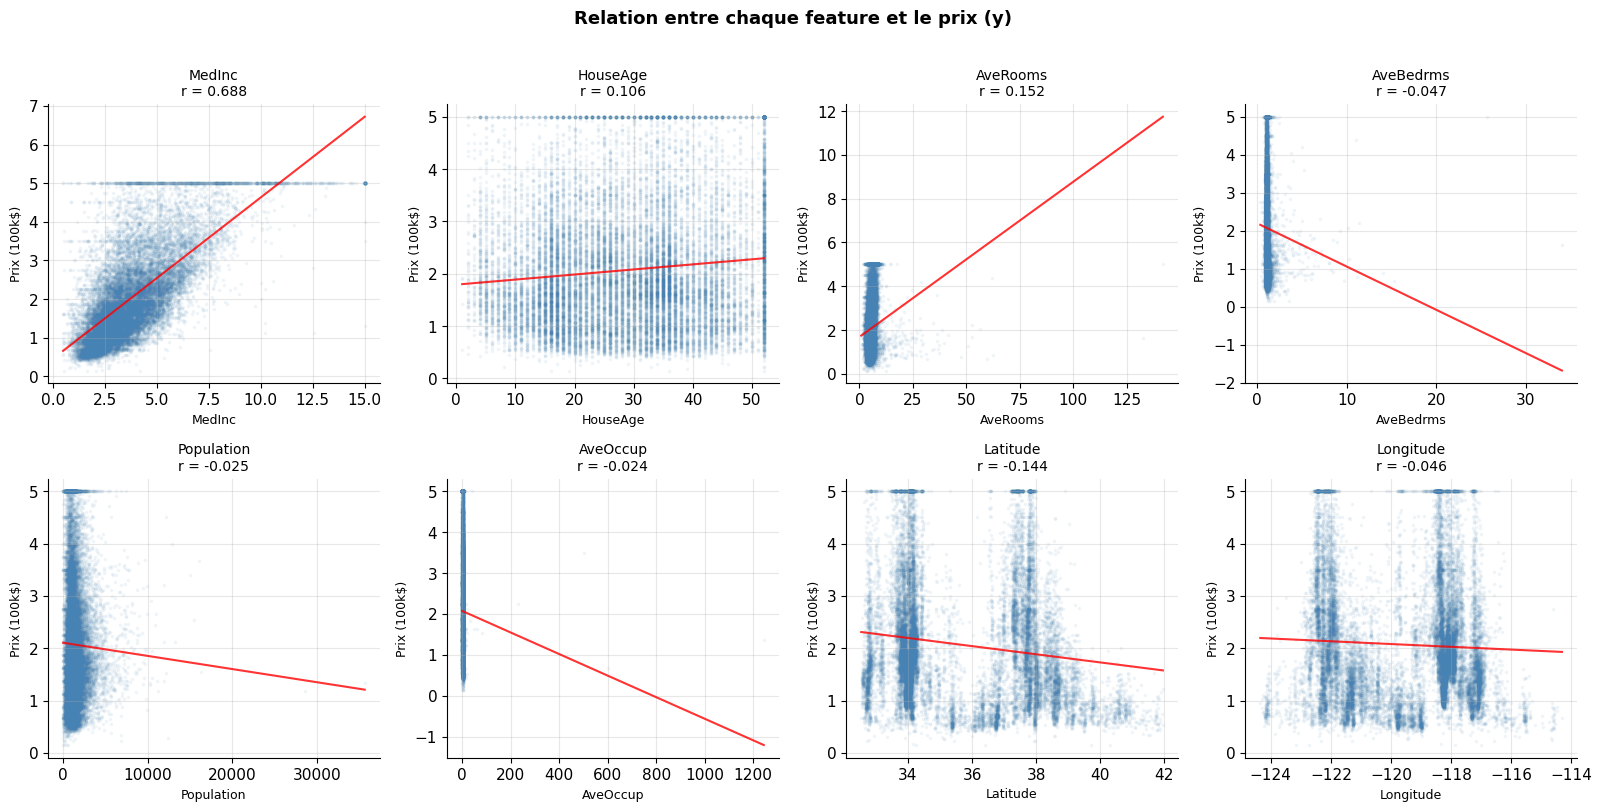


 Corrélations avec y (triées) :
MedInc        0.688
AveRooms      0.152
Latitude     -0.144
HouseAge      0.106
AveBedrms    -0.047
Longitude    -0.046
Population   -0.025
AveOccup     -0.024


In [6]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for i, col in enumerate(X.columns):
    ax = axes[i]
    ax.scatter(X[col], y, alpha=0.05, s=3, color='steelblue')
    # Ajouter une tendance linéaire
    z = np.polyfit(X[col], y, 1)
    p_line = np.poly1d(z)
    x_sorted = np.linspace(X[col].min(), X[col].max(), 100)
    ax.plot(x_sorted, p_line(x_sorted), 'r-', lw=1.5, alpha=0.8)
    corr = X[col].corr(y)
    ax.set_title(f'{col}\nr = {corr:.3f}', fontsize=10)
    ax.set_xlabel(col, fontsize=9)
    ax.set_ylabel('Prix (100k$)', fontsize=9)

plt.suptitle('Relation entre chaque feature et le prix (y)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\n Corrélations avec y (triées) :")
print(X.corrwith(y).sort_values(key=abs, ascending=False).round(3).to_string())

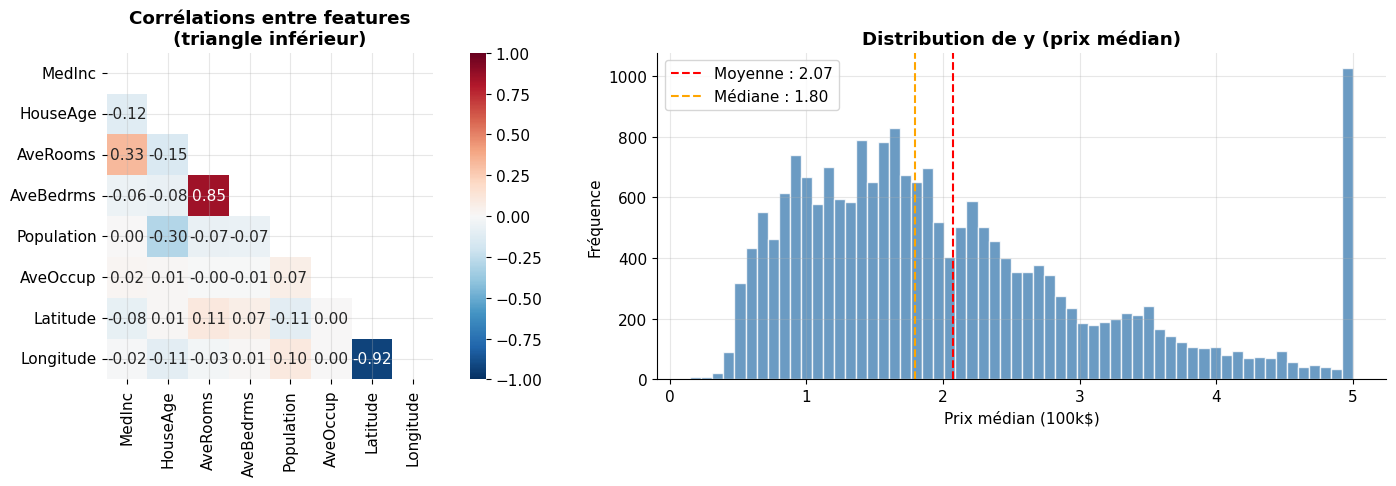


 Observations clés :
  • MedInc est la feature la + corrélée avec y (r ≈ 0.69) → candidate pour la régression simple
  • AveRooms et AveBedrms sont très corrélées entre elles → risque de multicolinéarité
  • y est plafonné à 5 (artefact de collecte) → à noter dans l'analyse des résidus


In [7]:
# ── Heatmap de corrélation entre features ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap
mask = np.triu(np.ones_like(X.corr(), dtype=bool))
sns.heatmap(X.corr(), mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=axes[0], square=True)
axes[0].set_title('Corrélations entre features\n(triangle inférieur)', fontweight='bold')

# Distribution de y
axes[1].hist(y, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(y.mean(), color='red', ls='--', lw=1.5, label=f'Moyenne : {y.mean():.2f}')
axes[1].axvline(y.median(), color='orange', ls='--', lw=1.5, label=f'Médiane : {y.median():.2f}')
axes[1].set_xlabel('Prix médian (100k$)'); axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution de y (prix médian)', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n Observations clés :")
print("  • MedInc est la feature la + corrélée avec y (r ≈ 0.69) → candidate pour la régression simple")
print("  • AveRooms et AveBedrms sont très corrélées entre elles → risque de multicolinéarité")
print("  • y est plafonné à 5 (artefact de collecte) → à noter dans l'analyse des résidus")

---
## Partie 2 — Régression linéaire simple
### 2.1 Le modèle : équation et interprétation des coefficients

La régression linéaire simple suppose une relation **linéaire** entre une feature `x` et la cible `y` :

$$\hat{y} = \beta_0 + \beta_1 \cdot x$$

| Paramètre | Nom | Interprétation |
|-----------|-----|----------------|
| $\beta_0$ | Intercept | Valeur prédite quand `x = 0` |
| $\beta_1$ | Pente | Variation de `ŷ` pour **+1 unité** de `x` |

>  **Exemple fil rouge** (MedInc → prix) :  
> - $\beta_0 \approx 0.45$ : quand le revenu médian est nul, le prix prédit est 45 000 $  
> - $\beta_1 \approx 0.42$ : +10 000 $ de revenu médian → +42 000 $ sur le prix prédit  

>  **La corrélation n'est pas la causalité.** Un $\beta_1$ élevé ne prouve pas que x *cause* y.


### 2.2 La fonction coût MSE

Comment trouver les "meilleurs" $\beta_0$ et $\beta_1$ ? On définit une **fonction coût** qui mesure l'erreur du modèle :

$$\text{MSE}(\beta_0, \beta_1) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 = \frac{1}{n} \sum_{i=1}^{n} (y_i - \beta_0 - \beta_1 x_i)^2$$

**Pourquoi le carré plutôt que la valeur absolue ?**
-  Fonction **dérivable** → optimisation analytique et par gradient possible
-  **Pénalise fortement** les grandes erreurs (erreur ×10 → coût ×100)
-  Solution analytique **unique** (convexe)
-  Sensible aux **outliers** — si robustesse nécessaire, préférer MAE

>  On utilise souvent **RMSE = √MSE** pour retrouver l'unité originale de y.


In [8]:
# ── Calculer la MSE manuellement — comprendre ce qu'on minimise ──────────────
x_simple = X['MedInc'].values
y_vals   = y.values

# Modèle nul : prédire la moyenne partout (baseline de référence)
y_pred_null = np.full(len(y_vals), y_vals.mean())
mse_null    = np.mean((y_vals - y_pred_null) ** 2)

# Modèle "à la main" avec des β estimés visuellement
beta0_essai, beta1_essai = 0.45, 0.42
y_pred_essai = beta0_essai + beta1_essai * x_simple
mse_essai    = np.mean((y_vals - y_pred_essai) ** 2)
rmse_essai   = np.sqrt(mse_essai)

print(f"MSE  modèle nul (prédire la moyenne) : {mse_null:.4f}")
print(f"MSE  modèle β₀=0.45, β₁=0.42        : {mse_essai:.4f}")
print(f"RMSE modèle essai                    : {rmse_essai:.4f}  "
      f"(soit ±{rmse_essai*100_000:.0f} $ d\'erreur typique)")
print()
print("Décomposition MSE sur les 5 premières observations :")
print(f"{'i':>4} {'y_i':>8} {'ŷ_i':>8} {'erreur':>10} {'erreur²':>12}")
print("-" * 48)
for i in range(5):
    err  = y_vals[i] - y_pred_essai[i]
    print(f"{i:>4} {y_vals[i]:>8.4f} {y_pred_essai[i]:>8.4f} {err:>10.4f} {err**2:>12.6f}")
print(f"{'':>44} MSE ≈ {mse_essai:.4f}")

MSE  modèle nul (prédire la moyenne) : 1.3316
MSE  modèle β₀=0.45, β₁=0.42        : 0.7012
RMSE modèle essai                    : 0.8374  (soit ±83738 $ d'erreur typique)

Décomposition MSE sur les 5 premières observations :
   i      y_i      ŷ_i     erreur      erreur²
------------------------------------------------
   0   4.5260   3.9466     0.5794     0.335723
   1   3.5850   3.9366    -0.3516     0.123614
   2   3.5210   3.4981     0.0229     0.000524
   3   3.4130   2.8201     0.5929     0.351528
   4   3.4220   2.0654     1.3566     1.840353
                                             MSE ≈ 0.7012


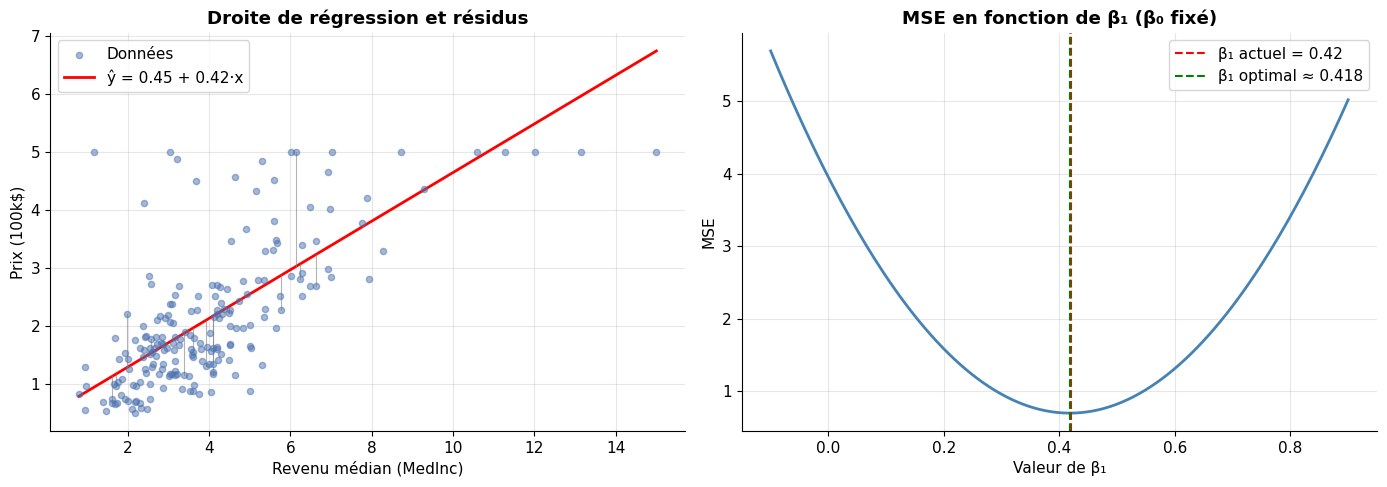

In [9]:
# ── Visualiser la MSE géométriquement ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gauche : droite de régression et résidus sur un échantillon
sample_idx = np.random.choice(len(x_simple), 200, replace=False)
xs, ys = x_simple[sample_idx], y_vals[sample_idx]
yp = beta0_essai + beta1_essai * xs

ax = axes[0]
ax.scatter(xs, ys, alpha=0.5, s=20, label='Données', zorder=3)
x_range = np.linspace(xs.min(), xs.max(), 100)
ax.plot(x_range, beta0_essai + beta1_essai * x_range,
        'r-', lw=2, label=f'ŷ = {beta0_essai} + {beta1_essai}·x')
# Dessiner quelques résidus
for xi, yi, ypi in zip(xs[:15], ys[:15], yp[:15]):
    ax.plot([xi, xi], [yi, ypi], 'gray', lw=0.8, alpha=0.6)
ax.set_xlabel('Revenu médian (MedInc)'); ax.set_ylabel('Prix (100k$)')
ax.set_title('Droite de régression et résidus', fontweight='bold')
ax.legend()

# Droite : surface de la MSE en fonction de β₁ (β₀ fixé)
b1_range = np.linspace(-0.1, 0.9, 200)
mses = [np.mean((y_vals - beta0_essai - b1 * x_simple)**2) for b1 in b1_range]
axes[1].plot(b1_range, mses, 'steelblue', lw=2)
axes[1].axvline(beta1_essai, color='red', ls='--', lw=1.5,
                label=f'β₁ actuel = {beta1_essai}')
min_idx = np.argmin(mses)
axes[1].axvline(b1_range[min_idx], color='green', ls='--', lw=1.5,
                label=f'β₁ optimal ≈ {b1_range[min_idx]:.3f}')
axes[1].set_xlabel('Valeur de β₁'); axes[1].set_ylabel('MSE')
axes[1].set_title('MSE en fonction de β₁ (β₀ fixé)', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

### 2.3 Descente de gradient

La descente de gradient est l'algorithme fondamental pour **minimiser** la fonction coût.  
Intuition : une bille qui roule vers le bas d'une vallée, pas à pas.

**Algorithme :**
1. Partir d'un point initial $(\beta_0, \beta_1)$ aléatoire
2. Calculer le gradient de MSE en ce point (direction de la *montée*)
3. Se déplacer dans la **direction opposée** (descente) d'un pas $\alpha$
4. Répéter jusqu'à convergence

$$\beta_0 \leftarrow \beta_0 - \alpha \cdot \frac{\partial \text{MSE}}{\partial \beta_0} \qquad \beta_1 \leftarrow \beta_1 - \alpha \cdot \frac{\partial \text{MSE}}{\partial \beta_1}$$

Avec les gradients calculés analytiquement :

$$\frac{\partial \text{MSE}}{\partial \beta_0} = \frac{-2}{n}\sum_i(y_i - \hat{y}_i) \qquad \frac{\partial \text{MSE}}{\partial \beta_1} = \frac{-2}{n}\sum_i(y_i - \hat{y}_i)\cdot x_i$$

>  **Erreur classique** : mettre à jour $\beta_0$ *puis* utiliser le nouveau $\beta_0$ pour calculer le gradient de $\beta_1$.  
>  **Correct** : calculer **les deux gradients** avec les valeurs actuelles, puis mettre à jour **simultanément**.

**Le learning rate $\alpha$ : paramètre critique**

| $\alpha$ | Comportement |
|-----------|-------------|
| Trop petit (< 0.0001) | Convergence très lente mais stable |
| Optimal (0.001–0.01) | Bon compromis vitesse / stabilité |
| Trop grand (> 0.1) | Oscillations, peut diverger |


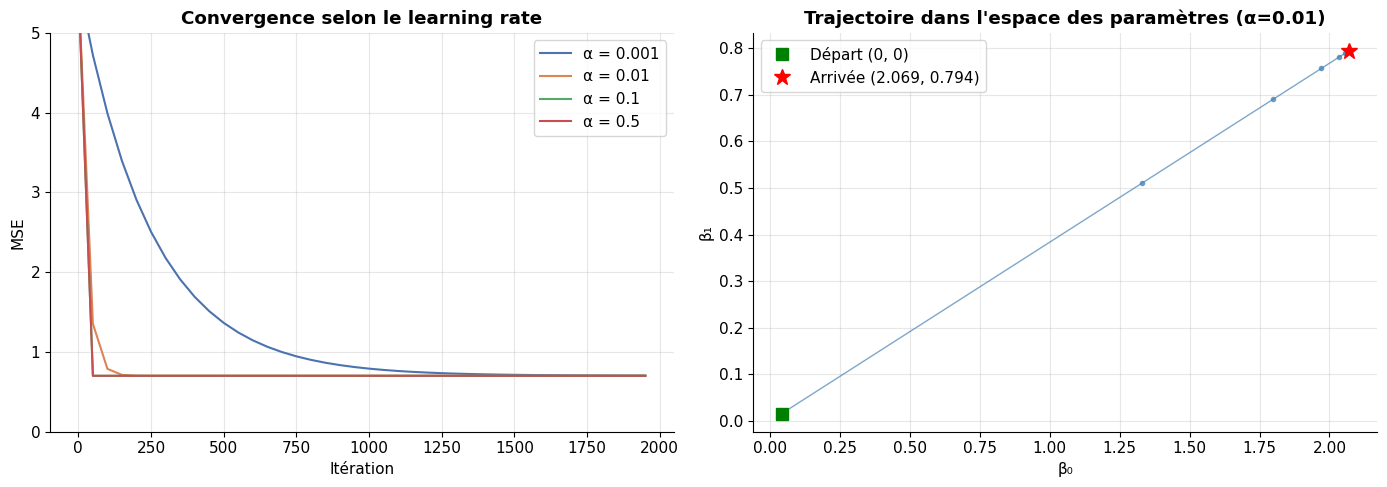


Résultat descente de gradient (α=0.01) :
  β₀ = 2.0686   β₁ = 0.7940   MSE finale = 0.7011


In [10]:
# ── Descente de gradient — implémentation from scratch ───────────────────────

def descente_gradient(x, y, alpha=0.01, n_iter=2000, verbose=True):
    """
    Descente de gradient pour la régression linéaire simple.
    
    Args:
        x      : feature (array 1D, standardisée de préférence)
        y      : cible (array 1D)
        alpha  : learning rate
        n_iter : nombre d'itérations
    
    Returns:
        beta0, beta1 : paramètres optimaux
        history      : liste de dict {iter, beta0, beta1, mse}
    """
    n       = len(y)
    beta0   = 0.0   # Initialisation
    beta1   = 0.0
    history = []

    for i in range(n_iter):
        # 1. Calculer les prédictions actuelles
        y_pred = beta0 + beta1 * x

        # 2. Calculer les gradients (dérivées partielles de MSE)
        erreur   = y_pred - y
        grad_b0  = (2 / n) * np.sum(erreur)
        grad_b1  = (2 / n) * np.sum(erreur * x)

        # 3. Mise à jour SIMULTANÉE (jamais séquentielle !)
        beta0 = beta0 - alpha * grad_b0
        beta1 = beta1 - alpha * grad_b1

        # 4. Enregistrer toutes les 50 itérations
        if i % 50 == 0:
            mse = np.mean(erreur ** 2)
            history.append({'iter': i, 'beta0': beta0,
                            'beta1': beta1, 'mse': mse})

    return beta0, beta1, history


# Standardiser x avant la descente (convergence beaucoup plus rapide)
x_std = (x_simple - x_simple.mean()) / x_simple.std()

# Comparer plusieurs learning rates
alphas = [0.001, 0.01, 0.1, 0.5]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results = {}
for alpha in alphas:
    b0, b1, hist = descente_gradient(x_std, y_vals, alpha=alpha, n_iter=2000)
    results[alpha] = (b0, b1, hist)
    iters = [h['iter'] for h in hist]
    mses  = [h['mse']  for h in hist]
    axes[0].plot(iters, mses, label=f'α = {alpha}', lw=1.5)

axes[0].set_xlabel('Itération'); axes[0].set_ylabel('MSE')
axes[0].set_title('Convergence selon le learning rate', fontweight='bold')
axes[0].legend(); axes[0].set_ylim(0, 5)

# Trajectoire dans l'espace (β₀, β₁) pour α=0.01
b0, b1, hist = results[0.01]
b0s = [h['beta0'] for h in hist]
b1s = [h['beta1'] for h in hist]
axes[1].plot(b0s, b1s, 'o-', ms=3, lw=1, color='steelblue', alpha=0.7)
axes[1].plot(b0s[0], b1s[0], 'gs', ms=8, label='Départ (0, 0)')
axes[1].plot(b0s[-1], b1s[-1], 'r*', ms=12, label=f'Arrivée ({b0:.3f}, {b1:.3f})')
axes[1].set_xlabel('β₀'); axes[1].set_ylabel('β₁')
axes[1].set_title('Trajectoire dans l\'espace des paramètres (α=0.01)', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nRésultat descente de gradient (α=0.01) :")
print(f"  β₀ = {b0:.4f}   β₁ = {b1:.4f}   MSE finale = {results[0.01][2][-1]['mse']:.4f}")

### 2.4 Implémentation avec scikit-learn

En pratique, scikit-learn utilise la **solution analytique OLS** (Ordinary Least Squares) :

$$\hat{\beta} = (X^\top X)^{-1} X^\top y$$

C'est la solution exacte — **pas d'itérations**. Complexité : $O(p^3 + np^2)$.  
Pour $p > 10\,000$ features, on préférera la descente de gradient (`SGDRegressor`).

**Workflow complet scikit-learn en 6 étapes :**
```
1. Préparer X (double crochet → shape (n, 1))
2. model = LinearRegression()
3. model.fit(X_train, y_train)
4. Lire les coefficients : model.intercept_, model.coef_
5. y_pred = model.predict(X_test)
6. Évaluer : MSE, RMSE, R²
```


In [12]:
# ── Régression linéaire simple avec scikit-learn ─────────────────────────────

# 1. Préparer les données (IMPORTANT : double crochet pour shape (n, 1))
X_simple_sk = X[['MedInc']]   # shape : (20640, 1)

# 2–3. Instancier et entraîner
model_simple = LinearRegression()
model_simple.fit(X_simple_sk, y)

# 4. Lire les coefficients appris
print("Paramètres appris par OLS :")
print(f"  β₀ (intercept) = {model_simple.intercept_:.4f}")
print(f"  β₁ (MedInc)    = {model_simple.coef_[0]:.4f}")
print()
print("Interprétation métier :")
print(f"  → Quand MedInc = 0 : prix prédit = {model_simple.intercept_*100_000:.0f} $")
print(f"  → +1 unité de MedInc (≈ +10k$/an) : prix prédit +{model_simple.coef_[0]*100_000:.0f} $")

# 5. Prédire
y_pred_simple = model_simple.predict(X_simple_sk)

# 6. Évaluer
mse_s  = mean_squared_error(y, y_pred_simple)
rmse_s = np.sqrt(mse_s)
r2_s   = r2_score(y, y_pred_simple)

print()
print("Métriques sur le dataset COMPLET :")
print(f"  MSE  = {mse_s:.4f}")
print(f"  RMSE = {rmse_s:.4f}  (±{rmse_s*100_000:.0f} $ d\'erreur typique)")
print(f"  R²   = {r2_s:.4f}  → le modèle explique {r2_s*100:.1f}% de la variance")

Paramètres appris par OLS :
  β₀ (intercept) = 0.4509
  β₁ (MedInc)    = 0.4179

Interprétation métier :
  → Quand MedInc = 0 : prix prédit = 45086 $
  → +1 unité de MedInc (≈ +10k$/an) : prix prédit +41794 $

Métriques sur le dataset COMPLET :
  MSE  = 0.7011
  RMSE = 0.8373  (±83734 $ d'erreur typique)
  R²   = 0.4734  → le modèle explique 47.3% de la variance


c:\Users\nessr\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


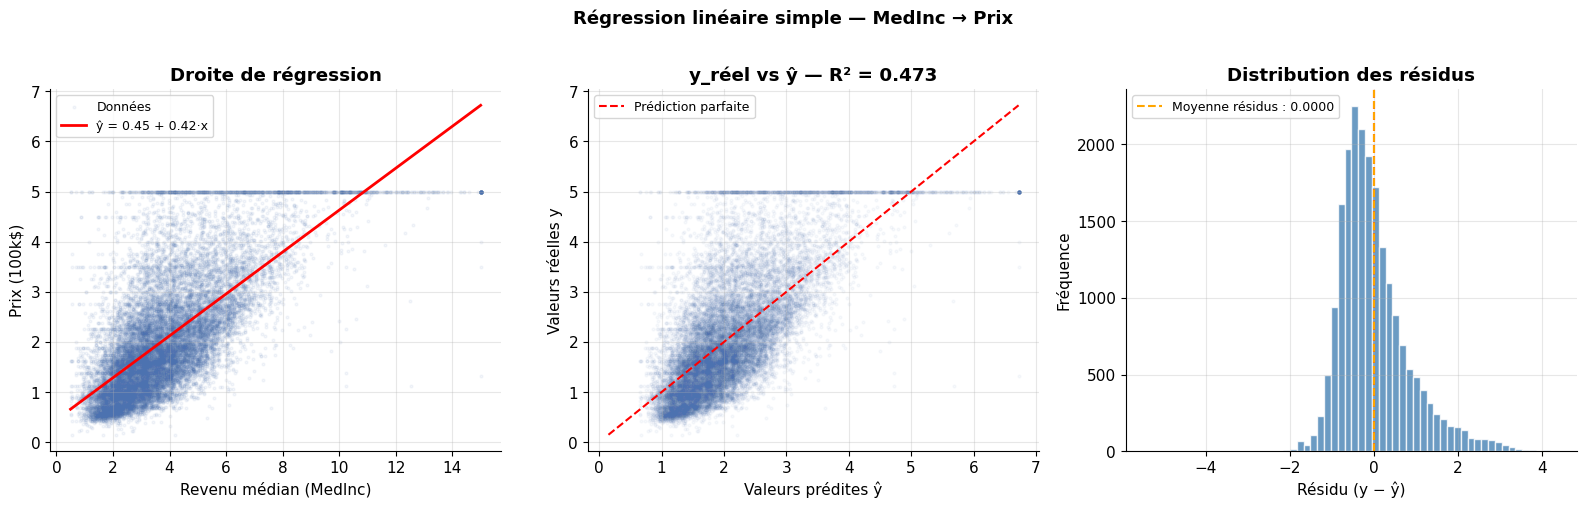


 Bilan régression simple :
  RMSE ≈ 0.84 soit ±84k$ d'erreur typique
  R² ≈ 0.47 : MedInc seul explique 47% de la variance
  Question : peut-on faire mieux en ajoutant les 7 autres features ?


In [14]:
# ── Visualisation complète : droite, résidus, performance ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Plot 1 : Données + droite de régression ---
ax = axes[0]
ax.scatter(X['MedInc'], y, alpha=0.06, s=4, label='Données')
x_range = np.linspace(X['MedInc'].min(), X['MedInc'].max(), 200).reshape(-1, 1)
ax.plot(x_range, model_simple.predict(x_range), 'r-', lw=2,
        label=f'ŷ = {model_simple.intercept_:.2f} + {model_simple.coef_[0]:.2f}·x')
ax.set_xlabel('Revenu médian (MedInc)'); ax.set_ylabel('Prix (100k$)')
ax.set_title('Droite de régression', fontweight='bold')
ax.legend(fontsize=9)

# --- Plot 2 : Valeurs réelles vs prédites ---
ax = axes[1]
ax.scatter(y_pred_simple, y, alpha=0.04, s=4)
lims = [min(y.min(), y_pred_simple.min()), max(y.max(), y_pred_simple.max())]
ax.plot(lims, lims, 'r--', lw=1.5, label='Prédiction parfaite')
ax.set_xlabel('Valeurs prédites ŷ'); ax.set_ylabel('Valeurs réelles y')
ax.set_title(f'y_réel vs ŷ — R² = {r2_s:.3f}', fontweight='bold')
ax.legend(fontsize=9)

# --- Plot 3 : Distribution des résidus ---
residus = y.values - y_pred_simple
ax = axes[2]
ax.hist(residus, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', ls='--', lw=1.5)
ax.axvline(residus.mean(), color='orange', ls='--', lw=1.5,
           label=f'Moyenne résidus : {residus.mean():.4f}')
ax.set_xlabel('Résidu (y − ŷ)'); ax.set_ylabel('Fréquence')
ax.set_title('Distribution des résidus', fontweight='bold')
ax.legend(fontsize=9)

plt.suptitle('Régression linéaire simple — MedInc → Prix',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\n Bilan régression simple :")
print(f"  RMSE ≈ {rmse_s:.2f} soit ±{rmse_s*100:.0f}k$ d\'erreur typique")
print(f"  R² ≈ {r2_s:.2f} : MedInc seul explique {r2_s*100:.0f}% de la variance")
print(f"  Question : peut-on faire mieux en ajoutant les 7 autres features ?")

---
## Partie 3 — Régression linéaire multiple
### 3.1 Extension au cas multiple

Avec $p$ features, le modèle devient :

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_p x_p = \beta_0 + \sum_{j=1}^{p} \beta_j x_j$$

En notation matricielle : $\hat{y} = X\beta$ où $X$ est de shape $(n \times p+1)$ avec une colonne de 1 en tête.

**Interprétation clé — la clause *ceteris paribus* :**  
$\beta_j$ = effet de $x_j$ sur $y$, **toutes les autres features maintenues constantes**.

>  **Paradoxe de Simpson** : un coefficient peut *changer de signe* entre régression simple et multiple.  
> Ex : $\beta_{\text{MedInc}}$ diminue en régression multiple car une partie de son effet est expliquée  
> par sa corrélation avec d'autres variables géographiques.


### 3.2 Multicolinéarité : diagnostic et conséquences

La multicolinéarité survient quand deux features ou plus sont **fortement corrélées entre elles**.

**Pourquoi c'est un problème ?**
- Les coefficients deviennent **instables** : une légère perturbation des données change massivement les β
- Les **erreurs standard** des coefficients explosent → intervalles de confiance inutilisables
- La **prédiction** reste souvent correcte, mais l'**interprétation** est invalide

**Diagnostic : VIF (Variance Inflation Factor)**

$$\text{VIF}(x_j) = \frac{1}{1 - R^2_j}$$

où $R^2_j$ est le $R^2$ de la régression de $x_j$ sur *toutes les autres features*.

| VIF | Interprétation |
|-----|---------------|
| 1 | Aucune colinéarité |
| 1–5 | Colinéarité modérée, acceptable |
| 5–10 | Colinéarité significative — surveiller |
| > 10 | Colinéarité sévère — action requise |


In [15]:
# ── Calcul du VIF pour chaque feature ────────────────────────────────────────

def compute_vif(X_df):
    """
    Calcule le VIF pour chaque colonne d'un DataFrame.
    VIF(xⱼ) = 1 / (1 - R²ⱼ)  où R²ⱼ = R² de xⱼ régressé sur les autres features.
    """
    vifs = {}
    for col in X_df.columns:
        X_other = X_df.drop(columns=col)
        y_col   = X_df[col]
        r2 = LinearRegression().fit(X_other, y_col).score(X_other, y_col)
        vifs[col] = round(1 / (1 - r2) if r2 < 1 else np.inf, 2)
    return pd.Series(vifs).sort_values(ascending=False)


vif = compute_vif(X)

# Affichage avec code couleur
print("VIF par feature :")
print("-" * 35)
for feature, val in vif.items():
    if val > 10:
        flag = " SÉVÈRE"
    elif val > 5:
        flag = " Attention"
    else:
        flag = " OK"
    print(f"  {feature:<14} {val:>6.2f}  {flag}")

VIF par feature :
-----------------------------------
  Latitude         9.30   Attention
  Longitude        8.96   Attention
  AveRooms         8.34   Attention
  AveBedrms        6.99   Attention
  MedInc           2.50   OK
  HouseAge         1.24   OK
  Population       1.14   OK
  AveOccup         1.01   OK


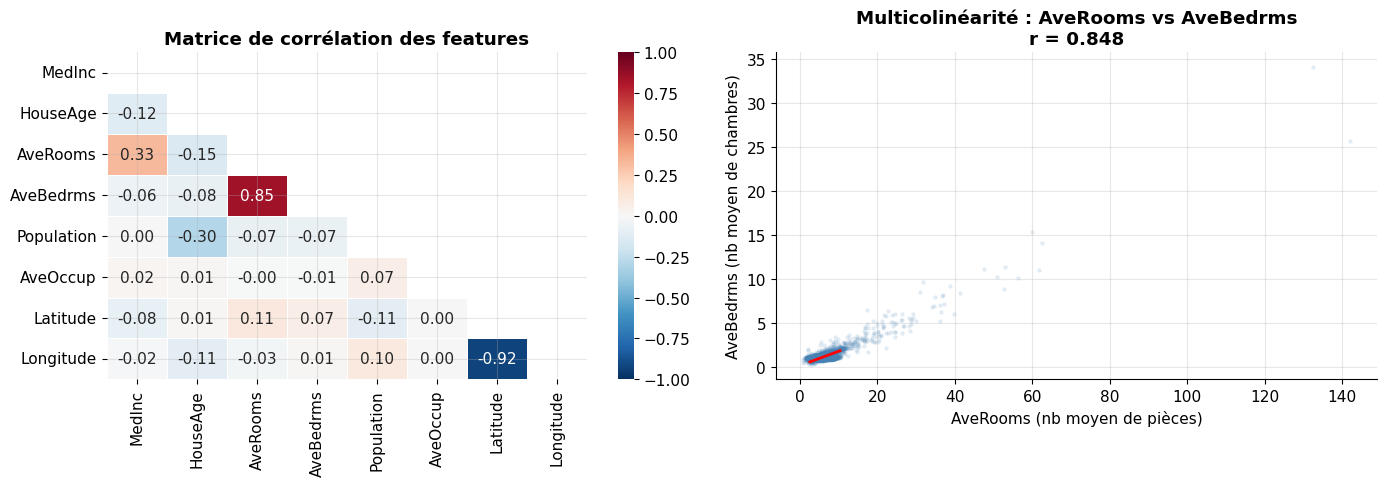


 AveRooms et AveBedrms ont r ≈ 0.85 → multicolinéarité forte
   → En régression multiple, leurs coefficients seront instables
   → Solution : supprimer l'une, créer un ratio, ou utiliser Ridge/Lasso (Cours 2)


In [16]:
# ── Visualisation de la multicolinéarité ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap annotée
mask = np.triu(np.ones_like(X.corr(), dtype=bool))
g = sns.heatmap(X.corr(), mask=mask, annot=True, fmt='.2f',
                cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                ax=axes[0], linewidths=0.5)
axes[0].set_title('Matrice de corrélation des features', fontweight='bold')

# Scatter AveRooms vs AveBedrms (pair le plus problématique)
axes[1].scatter(X['AveRooms'], X['AveBedrms'], alpha=0.1, s=5, color='steelblue')
corr_val = X['AveRooms'].corr(X['AveBedrms'])
axes[1].set_xlabel('AveRooms (nb moyen de pièces)')
axes[1].set_ylabel('AveBedrms (nb moyen de chambres)')
axes[1].set_title(f'Multicolinéarité : AveRooms vs AveBedrms\nr = {corr_val:.3f}',
                  fontweight='bold')

# Ajouter droite de tendance
z = np.polyfit(X['AveRooms'], X['AveBedrms'], 1)
p_line = np.poly1d(z)
x_r = np.linspace(X['AveRooms'].quantile(0.01), X['AveRooms'].quantile(0.99), 100)
axes[1].plot(x_r, p_line(x_r), 'r-', lw=2)

plt.tight_layout()
plt.show()

print("\n AveRooms et AveBedrms ont r ≈ 0.85 → multicolinéarité forte")
print("   → En régression multiple, leurs coefficients seront instables")
print("   → Solution : supprimer l'une, créer un ratio, ou utiliser Ridge/Lasso (Cours 2)")

### 3.3 Standardisation des variables

La standardisation ramène toutes les features à **la même échelle** :

$$x'_j = \frac{x_j - \mu_j}{\sigma_j}$$

Résultat : moyenne = 0, écart-type = 1 pour chaque feature.

**Quand standardiser ?**

| Situation | Standardiser ? | Raison |
|-----------|---------------|--------|
| Régression OLS pure | Optionnel | La solution analytique est invariante à l'échelle |
| Descente de gradient | **Obligatoire** | Convergence beaucoup plus rapide |
| Ridge / Lasso | **Obligatoire** | La pénalité s'applique aux coefficients : doivent être comparables |
| Interprétation des β | Recommandé | Coefficients standardisés = importance relative des features |
| Variable binaire (0/1) | Non | Une indicatrice n'a pas besoin d'être centrée |

>  **Règle d'or — à ne jamais oublier :**  
> `scaler.fit()` **uniquement sur X_train**, puis `scaler.transform()` sur X_train ET X_test.  
> Appliquer `fit_transform()` sur tout le dataset avant le split = **data leakage**   
> *(Démonstration et conséquences dans le Cours 2)*


Feature 'MedInc' — AVANT standardisation :
  Moyenne : 3.8707
  Std     : 1.8998
  Min / Max : [0.4999, 15.0001]

Feature 'MedInc' — APRÈS standardisation :
  Moyenne : 0.000000  (≈ 0)
  Std     : 1.000000   (= 1)
  Min / Max : [-1.7743, 5.8583]


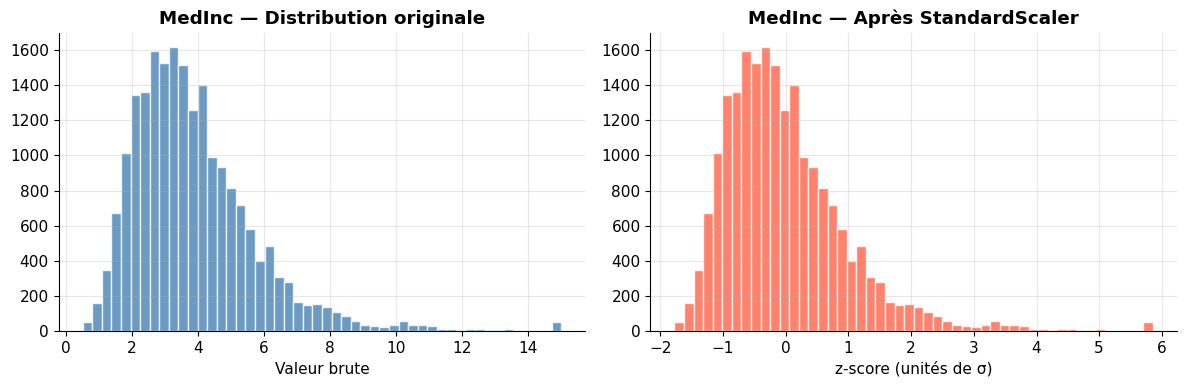

In [17]:
# ── Standardisation manuelle — voir ce que ça fait ───────────────────────────

feature = 'MedInc'
x_raw = X[feature].values

mu    = x_raw.mean()
sigma = x_raw.std()
x_std_manual = (x_raw - mu) / sigma

print(f"Feature '{feature}' — AVANT standardisation :")
print(f"  Moyenne : {x_raw.mean():.4f}")
print(f"  Std     : {x_raw.std():.4f}")
print(f"  Min / Max : [{x_raw.min():.4f}, {x_raw.max():.4f}]")
print()
print(f"Feature '{feature}' — APRÈS standardisation :")
print(f"  Moyenne : {x_std_manual.mean():.6f}  (≈ 0)")
print(f"  Std     : {x_std_manual.std():.6f}   (= 1)")
print(f"  Min / Max : [{x_std_manual.min():.4f}, {x_std_manual.max():.4f}]")

# Visualiser
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(x_raw, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('MedInc — Distribution originale', fontweight='bold')
axes[0].set_xlabel('Valeur brute')

axes[1].hist(x_std_manual, bins=50, color='tomato', edgecolor='white', alpha=0.8)
axes[1].set_title('MedInc — Après StandardScaler', fontweight='bold')
axes[1].set_xlabel('z-score (unités de σ)')

plt.tight_layout()
plt.show()

In [18]:
# ── Régression multiple avec Pipeline sklearn ─────────────────────────────────
#
#   Pipeline = enchaînement ordonné d'étapes de transformation + modèle
#   Avantage : une seule ligne pour fit() et predict() → évite les erreurs
#

pipe = Pipeline([
    ('scaler',     StandardScaler()),    # Étape 1 : standardiser toutes les features
    ('regression', LinearRegression()),  # Étape 2 : entraîner la régression
])

# Entraîner (⚠️ sur tout le dataset ici — le split est dans le TP 1)
pipe.fit(X, y)
y_pred_multi = pipe.predict(X)

# Métriques
mse_m  = mean_squared_error(y, y_pred_multi)
rmse_m = np.sqrt(mse_m)
r2_m   = r2_score(y, y_pred_multi)

print("=" * 55)
print("  Régression linéaire MULTIPLE — 8 features")
print("=" * 55)
print(f"  RMSE = {rmse_m:.4f}  (±{rmse_m*100:.0f}k$)")
print(f"  R²   = {r2_m:.4f}  ({r2_m*100:.1f}% de variance expliquée)")
print()
print(f"  Comparaison vs régression simple (MedInc seul) :")
print(f"  RMSE : {rmse_s:.4f} → {rmse_m:.4f}  (gain : {(rmse_s - rmse_m)/rmse_s*100:.1f}%)")
print(f"  R²   : {r2_s:.4f} → {r2_m:.4f}  (+{(r2_m - r2_s)*100:.1f} points)")

  Régression linéaire MULTIPLE — 8 features
  RMSE = 0.7241  (±72k$)
  R²   = 0.6062  (60.6% de variance expliquée)

  Comparaison vs régression simple (MedInc seul) :
  RMSE : 0.8373 → 0.7241  (gain : 13.5%)
  R²   : 0.4734 → 0.6062  (+13.3 points)


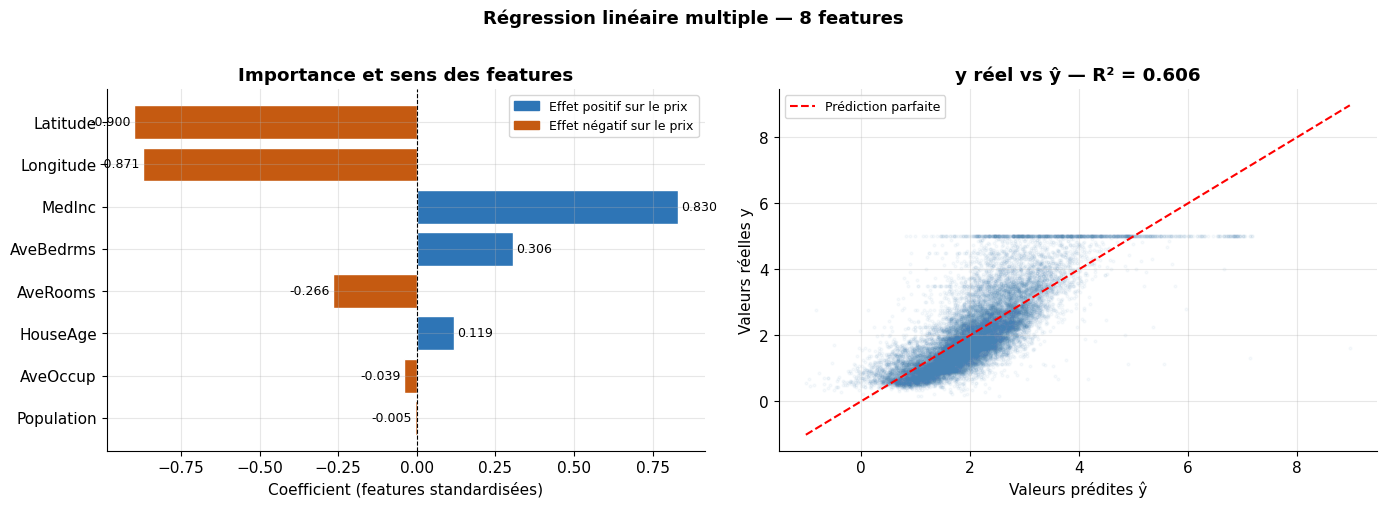


Interprétation des coefficients (standardisés) :
------------------------------------------------------------
  Latitude        -0.8999   ↓ Prix
  Longitude       -0.8705   ↓ Prix
  MedInc           0.8296   ↑ Prix
  AveBedrms        0.3057   ↑ Prix
  AveRooms        -0.2655   ↓ Prix
  HouseAge         0.1188   ↑ Prix
  AveOccup        -0.0393   ↓ Prix
  Population      -0.0045   ↓ Prix

  Intercept : 2.0686


In [19]:
# ── Visualiser et interpréter les coefficients ───────────────────────────────

# Récupérer les coefficients standardisés depuis le pipeline
coef_values = pipe.named_steps['regression'].coef_
intercept   = pipe.named_steps['regression'].intercept_

coef_df = pd.DataFrame({
    'feature': X.columns,
    'coef':    coef_values,
    'abs_coef': np.abs(coef_values)
}).sort_values('abs_coef', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot horizontal des coefficients
colors = ['#2E75B6' if c > 0 else '#C55A11' for c in coef_df['coef']]
axes[0].barh(coef_df['feature'], coef_df['coef'], color=colors, edgecolor='white')
axes[0].axvline(0, color='black', lw=0.8, ls='--')
axes[0].set_xlabel('Coefficient (features standardisées)')
axes[0].set_title('Importance et sens des features', fontweight='bold')

# Annoter
for i, (v, name) in enumerate(zip(coef_df['coef'], coef_df['feature'])):
    offset = 0.01 if v >= 0 else -0.01
    axes[0].text(v + offset, i, f'{v:.3f}', va='center', fontsize=9,
                 ha='left' if v >= 0 else 'right')

# Légende manuelle
blue_patch  = mpatches.Patch(color='#2E75B6', label='Effet positif sur le prix')
orange_patch = mpatches.Patch(color='#C55A11', label='Effet négatif sur le prix')
axes[0].legend(handles=[blue_patch, orange_patch], fontsize=9)

# Scatter y_réel vs ŷ
axes[1].scatter(y_pred_multi, y, alpha=0.04, s=4, color='steelblue')
lims = [min(y.min(), y_pred_multi.min()), max(y.max(), y_pred_multi.max())]
axes[1].plot(lims, lims, 'r--', lw=1.5, label='Prédiction parfaite')
axes[1].set_xlabel('Valeurs prédites ŷ'); axes[1].set_ylabel('Valeurs réelles y')
axes[1].set_title(f'y réel vs ŷ — R² = {r2_m:.3f}', fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Régression linéaire multiple — 8 features', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\nInterprétation des coefficients (standardisés) :")
print("-" * 60)
for _, row in coef_df.sort_values('abs_coef', ascending=False).iterrows():
    sens = "↑ Prix" if row['coef'] > 0 else "↓ Prix"
    print(f"  {row['feature']:<14} {row['coef']:>8.4f}   {sens}")
print(f"\n  Intercept : {intercept:.4f}")

### 3.4 Comparer régression simple vs multiple

Un tableau récapitulatif de ce que gagne chaque feature ajoutée :


 nb_features   RMSE     R²                                                                         features
           1 0.8373 0.4734                                                                           MedInc
           2 0.8326 0.4794                                                                 MedInc, AveRooms
           3 0.8275 0.4857                                                       MedInc, AveRooms, Latitude
           4 0.8003 0.5190                                             MedInc, AveRooms, Latitude, HouseAge
           5 0.7820 0.5407                                  MedInc, AveRooms, Latitude, HouseAge, AveBedrms
           6 0.7252 0.6050                       MedInc, AveRooms, Latitude, HouseAge, AveBedrms, Longitude
           7 0.7252 0.6051           MedInc, AveRooms, Latitude, HouseAge, AveBedrms, Longitude, Population
           8 0.7241 0.6062 MedInc, AveRooms, Latitude, HouseAge, AveBedrms, Longitude, Population, AveOccup


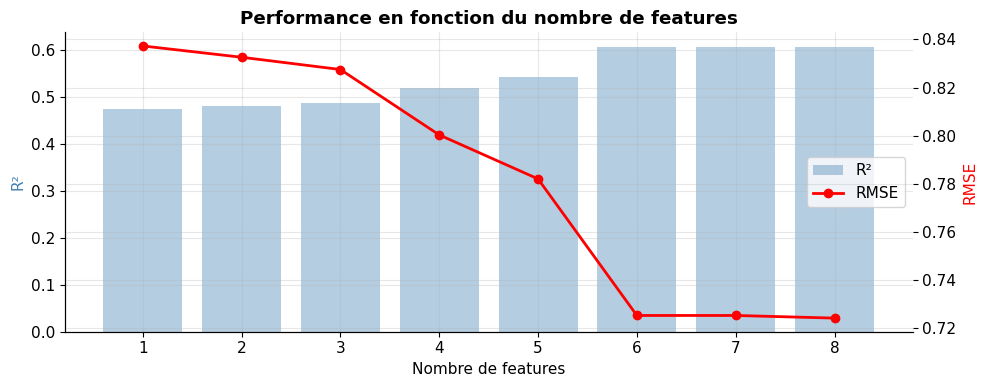

In [20]:
# ── Impact de chaque feature ajoutée successivement ──────────────────────────

# Ordre d'ajout : par corrélation décroissante avec y
feature_order = X.corrwith(y).abs().sort_values(ascending=False).index.tolist()

results_incremental = []
for k in range(1, len(feature_order) + 1):
    feats = feature_order[:k]
    pipe_k = Pipeline([
        ('scaler',     StandardScaler()),
        ('regression', LinearRegression()),
    ])
    pipe_k.fit(X[feats], y)
    y_p  = pipe_k.predict(X[feats])
    rmse = np.sqrt(mean_squared_error(y, y_p))
    r2   = r2_score(y, y_p)
    results_incremental.append({
        'nb_features': k,
        'features': ', '.join(feats),
        'RMSE': round(rmse, 4),
        'R²': round(r2, 4)
    })

df_incr = pd.DataFrame(results_incremental)
print(df_incr[['nb_features', 'RMSE', 'R²', 'features']].to_string(index=False))

# Graphique
fig, ax = plt.subplots(figsize=(10, 4))
ax2 = ax.twinx()
ax.bar(df_incr['nb_features'], df_incr['R²'], alpha=0.4, color='steelblue', label='R²')
ax2.plot(df_incr['nb_features'], df_incr['RMSE'], 'ro-', lw=2, ms=6, label='RMSE')
ax.set_xlabel('Nombre de features')
ax.set_ylabel('R²', color='steelblue')
ax2.set_ylabel('RMSE', color='red')
ax.set_title('Performance en fonction du nombre de features', fontweight='bold')
ax.set_xticks(df_incr['nb_features'])
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='center right')
plt.tight_layout()
plt.show()

---
##  Synthèse — Récapitulatif du Cours 1

### Formules à retenir

| Formule | Description |
|---------|-------------|
| $\hat{y} = \beta_0 + \beta_1 x$ | Régression linéaire simple |
| $\hat{y} = \beta_0 + \sum_j \beta_j x_j$ | Régression linéaire multiple |
| $\hat{\beta} = (X^\top X)^{-1} X^\top y$ | Solution analytique OLS |
| $\text{MSE} = \frac{1}{n}\sum(y - \hat{y})^2$ | Fonction coût (à minimiser) |
| $\text{RMSE} = \sqrt{\text{MSE}}$ | Erreur en unités de y |
| $R^2 = 1 - \frac{\text{MSE}}{\text{Var}(y)}$ | Part de variance expliquée ∈ (−∞, 1] |
| $\beta \leftarrow \beta - \alpha \cdot \nabla\text{MSE}$ | Mise à jour descente de gradient |
| $\text{VIF}(x_j) = \frac{1}{1 - R^2_j}$ | Diagnostic de multicolinéarité |
| $x'_j = \frac{x_j - \mu_j}{\sigma_j}$ | Standardisation (StandardScaler) |

---

### Workflow à systématiser

```
1. Explorer    → Visualiser X, y, corrélations, distributions
2. Séparer     → train_test_split ( AVANT le scaler !)
3. Scaler      → StandardScaler : fit(train), transform(train + test)
4. Fitter      → LinearRegression().fit(X_train_std, y_train)
5. Prédire     → .predict(X_test_std)
6. Évaluer     → MSE, RMSE, R², analyse des résidus
7. Interpréter → .coef_, .intercept_, VIF
```

---

### Checklist avant le TP 1

- [ ] Je distingue régression et classification selon la nature de y
- [ ] Je sais interpréter β₀ et β₁ sur un exemple concret
- [ ] Je comprends ce que mesure la MSE et pourquoi on l'élève au carré
- [ ] Je comprends le principe de la descente de gradient (direction, α, convergence)
- [ ] Je sais pourquoi la mise à jour simultanée des β est obligatoire
- [ ] Je code une régression simple et multiple en sklearn en 5 lignes
- [ ] Je comprends ce que fait StandardScaler et dans quel ordre l'appliquer
- [ ] Je sais calculer le VIF et interpréter une heatmap de corrélation
- [ ] **Je comprends qu'un R² = 0.61 sur le dataset complet ne prouve rien sur la généralisation**


In [22]:
# ── Tableau de bord final ─────────────────────────────────────────────────────
print("=" * 60)
print("  BILAN — Cours 1 : Régression linéaire sur California Housing")
print("=" * 60)

# Régression simple
print("\n  1. Régression SIMPLE (MedInc seul)")
print(f"     RMSE = {rmse_s:.4f}  |  R² = {r2_s:.4f}")
print(f"     → ±{rmse_s*100:.0f}k$ d\'erreur typique")
print(f"     → MedInc explique {r2_s*100:.1f}% de la variance")

# Régression multiple
print("\n  2. Régression MULTIPLE (8 features)")
print(f"     RMSE = {rmse_m:.4f}  |  R² = {r2_m:.4f}")
print(f"     → ±{rmse_m*100:.0f}k$ d\'erreur typique")
print(f"     → Les 8 features expliquent {r2_m*100:.1f}% de la variance")

# Gain
print(f"\n  Gain multiple vs simple :")
print(f"     RMSE : -{(rmse_s - rmse_m)/rmse_s*100:.1f}% d\'erreur")
print(f"     R²   : +{(r2_m - r2_s)*100:.1f} points")
print("\n  3. Multicolinéarité :")
print("     • AveRooms et AveBedrms ont VIF > 10 → multicolinéarité sévère")
print("     • Risque : coefficients instables, interprétation difficile")
print("     • Solution : supprimer l\'une, créer un ratio, ou utiliser Ridge/Lasso (Cours 2)")
print("\n  4. Interprétation des coefficients :")
for _, row in coef_df.sort_values('abs_coef', ascending=False).iterrows():
    sens = "↑ Prix" if row['coef'] > 0 else "↓ Prix"
    print(f"     • {row['feature']:<14} {row['coef']:>8.4f}   {sens}")

  BILAN — Cours 1 : Régression linéaire sur California Housing

  1. Régression SIMPLE (MedInc seul)
     RMSE = 0.8373  |  R² = 0.4734
     → ±84k$ d'erreur typique
     → MedInc explique 47.3% de la variance

  2. Régression MULTIPLE (8 features)
     RMSE = 0.7241  |  R² = 0.6062
     → ±72k$ d'erreur typique
     → Les 8 features expliquent 60.6% de la variance

  Gain multiple vs simple :
     RMSE : -13.5% d'erreur
     R²   : +13.3 points

  3. Multicolinéarité :
     • AveRooms et AveBedrms ont VIF > 10 → multicolinéarité sévère
     • Risque : coefficients instables, interprétation difficile
     • Solution : supprimer l'une, créer un ratio, ou utiliser Ridge/Lasso (Cours 2)

  4. Interprétation des coefficients :
     • Latitude        -0.8999   ↓ Prix
     • Longitude       -0.8705   ↓ Prix
     • MedInc           0.8296   ↑ Prix
     • AveBedrms        0.3057   ↑ Prix
     • AveRooms        -0.2655   ↓ Prix
     • HouseAge         0.1188   ↑ Prix
     • AveOccup        -0.0